**Author:** Brendan OConnell 

**Date:** April 2026  

**Purpose:** Non-Linear EDA [Appendix] via UMAP on NFI particle dataset.
             This is an appendix to the main umap.ipynb for NFI EDA.

**Key decisions:**  

* No hyperparameter tunings from this NB yield any positive insights that differ from the main UMAP notebook.
* `n_neighbors=5` is too small for the NFI dataset and results in a UMAP warning about isolated clusters.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# ML
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import umap

# Viz
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import glasbey  # for colorblind palette
import seaborn as sns  # for colorblind palette

# KNN metric evaluation
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

c:\git\datascience-capstone\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
parquet_path = Path("../../../data/processed/particle_labeled.parquet")
nfi_df = pd.read_parquet(parquet_path)
nfi_df.shape

FileNotFoundError: [Errno 2] No such file or directory: '..\\..\\data\\processed\\particle_labeled.parquet'

In [ ]:
# Isolate element columns
element_cols = list(nfi_df.loc[:, "ac":"zr"].columns)

In [ ]:
# Use non-zero rates from particle_eda.ipynb to filter out non-informative elements
nonzero_rates = (nfi_df[element_cols] > 0).mean().sort_values(ascending=False)
informative_cols = sorted(nonzero_rates[nonzero_rates > 0.01].index.tolist())
len(informative_cols)

27

In [ ]:
# Binary filter
binary = nfi_df[nfi_df["label"].isin(["GSR", "Non_GSR"])]

# Sample 10% to save my laptop  :)
sample, _ = train_test_split(
    binary,
    train_size=0.1,
    stratify=binary["label"],  # stratify to maintain class balance
    random_state=42,
)

f"Sample size: {len(sample):,}"

'Sample size: 229,498'

In [ ]:
X_sample = sample[informative_cols].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

In [ ]:
# kNN classification accuracy
# Tests whether neighbors in the embedding share labels
X_umap_np = np.array(X_umap)
knn = KNeighborsClassifier(n_neighbors=15)
labels = np.array(sample["label"].values)
knn_umap = cross_val_score(knn, X_umap_np, labels, cv=5, scoring="accuracy").mean()

f"kNN classification accuracy: {knn_umap * 100:.1f}%"

'kNN classification accuracy: 94.0%'

In [ ]:
"""Hyperparameter exploratory tuning"""

'Hyperparameter exploratory tuning'

In [ ]:
# Cosine metric:
#   measures the angle between vectors, which can be more meaningful for high-dimensional sparse data like elemental compositions.
#   It focuses on the direction of the data points rather than their magnitude,
#   making it effective for distinguishing particles based on their compositional patterns rather than absolute concentrations.
#   This can help reveal clusters of particles with similar elemental profiles, even if their overall abundances differ.

reducer_cos = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42,
    low_memory=True,
    n_jobs=1
)
X_umap_cos = reducer_cos.fit_transform(X_scaled)

c:\git\datascience-capstone\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


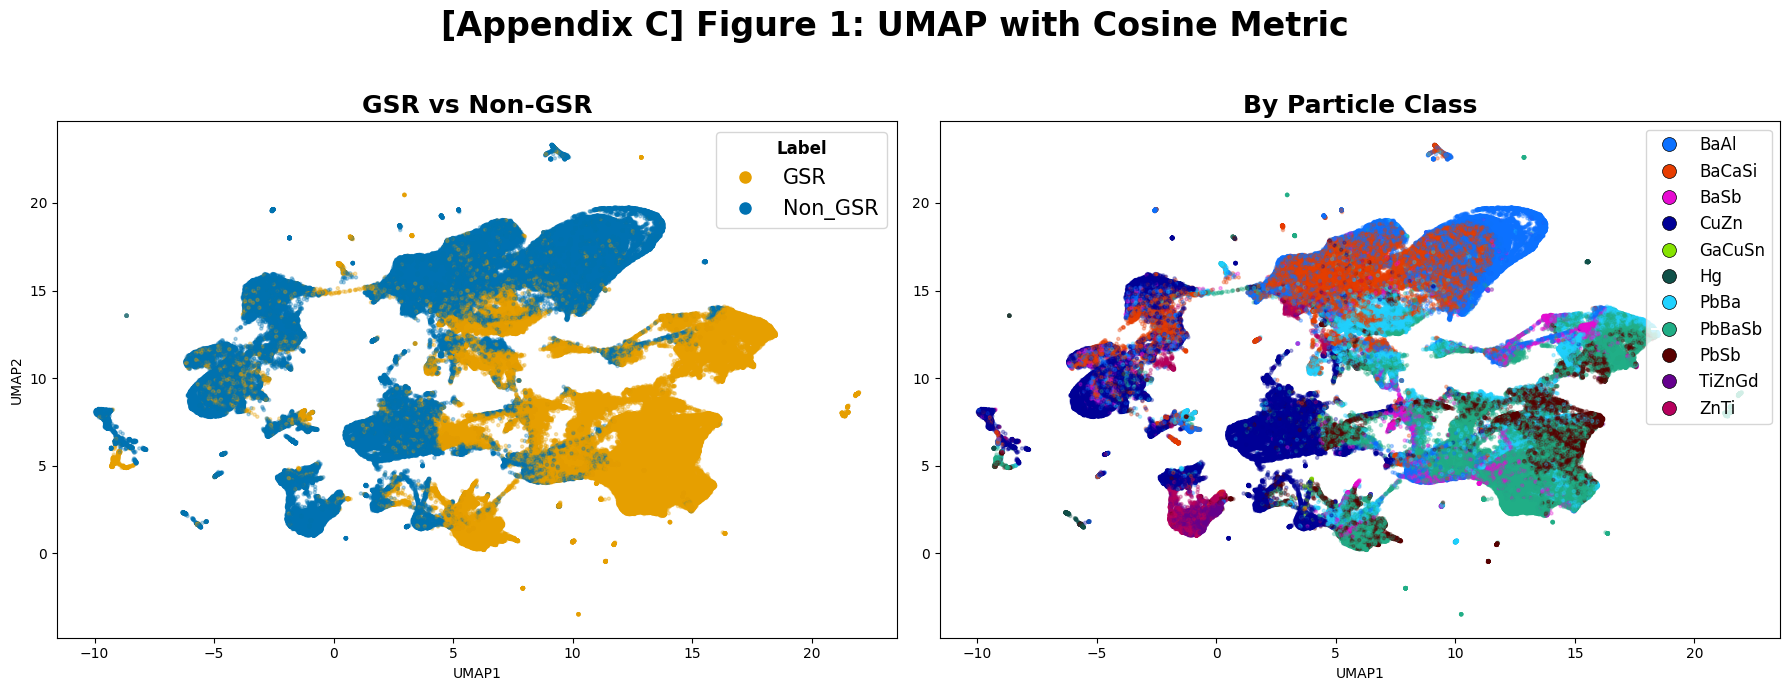

In [ ]:
# APPENDIX C - Figure 1

# Plot the UMAP results (2 plots) colored by: 1) binary label; 2) particle class
le = LabelEncoder()
class_encoded = le.fit_transform(sample["final_class"])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Colorblind friendly colors
colors = (
    sample["label"]
    .map({"GSR": "#E69F00", "Non_GSR": "#0072B2"})  # orange  # blue
    .values
)
# palette = sns.color_palette("colorblind", n_colors=len(le.classes_))
palette = glasbey.create_palette(palette_size=len(le.classes_), colorblind_safe=True)
point_colors = [palette[i] for i in class_encoded]

# scatter plot for binary labels
axes[0].scatter(X_umap_cos[:, 0], X_umap_cos[:, 1], c=colors, alpha=0.3, s=5)
axes[0].set_title("GSR vs Non-GSR", fontsize=18, fontweight="bold")
axes[0].set_xlabel("UMAP1")
axes[0].set_ylabel("UMAP2")

# legend for binary labels
handles = [
    mlines.Line2D(
        [], [], color=colors[1], marker="o", linestyle="None", markersize=8, label="GSR"
    ),
    mlines.Line2D(
        [],
        [],
        color=colors[0],
        marker="o",
        linestyle="None",
        markersize=8,
        label="Non_GSR",
    ),
]
bin_legend = axes[0].legend(handles=handles, loc="upper right", fontsize=15)
bin_legend.set_title("Label", prop={"size": 12, "weight": "bold"})
title = bin_legend.get_title()

# scatter plot for particle classes
scatter = axes[1].scatter(
    X_umap_cos[:, 0], X_umap_cos[:, 1], c=point_colors, alpha=0.3, s=5
)
axes[1].set_title("By Particle Class", fontsize=18, fontweight="bold")
axes[1].set_xlabel("UMAP1")

# custom legend for particle classes
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=palette[i],
        markersize=10,
        markeredgecolor="black",
        markeredgewidth=0.5,
        label=cls,
    )
    for i, cls in enumerate(sorted(le.classes_))
]
axes[1].legend(handles=handles, loc="upper right", fontsize=12, ncol=1, markerscale=1)

fig.suptitle(
    "[Appendix C] Figure 1: UMAP with Cosine Metric",
    fontsize=24,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig("outputs/umap__gsr_vs_non_gsr_2.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# kNN classification accuracy
X_umap_cos_np = np.array(X_umap_cos)
knn = KNeighborsClassifier(n_neighbors=15)
labels = np.array(sample["label"].values)
knn_umap_cos = cross_val_score(
    knn, X_umap_cos_np, labels, cv=5, scoring="accuracy"
).mean()

f"kNN classification accuracy: {knn_umap_cos * 100:.1f}%"

'kNN classification accuracy: 93.7%'

**Cosine metric does not appear to be visually better at separating GSR vs Non-GSR in UMAP space, and kNN accuracy is about the same.**

In [ ]:
# Nearest Neighbor metric:
#   n_neighbors=5 will produce tighter/more fragmented clusters, emphasizing fine-grained chemical subtypes

reducer_nn5 = umap.UMAP(
    n_neighbors=5,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42,
    low_memory=True,
    n_jobs=1
)
X_umap_nn5 = reducer_nn5.fit_transform(X_scaled)

c:\git\datascience-capstone\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\git\datascience-capstone\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


**NOTE**: Appendix C - Figure 2 sets `n_neighbors=5`, prompting the following warning:
> c:\git\datascience-capstone\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(

**This warning indicates that n_neighbors is too small for the data's structure, so isolated clusters or outliers don't connect to the main graph.**

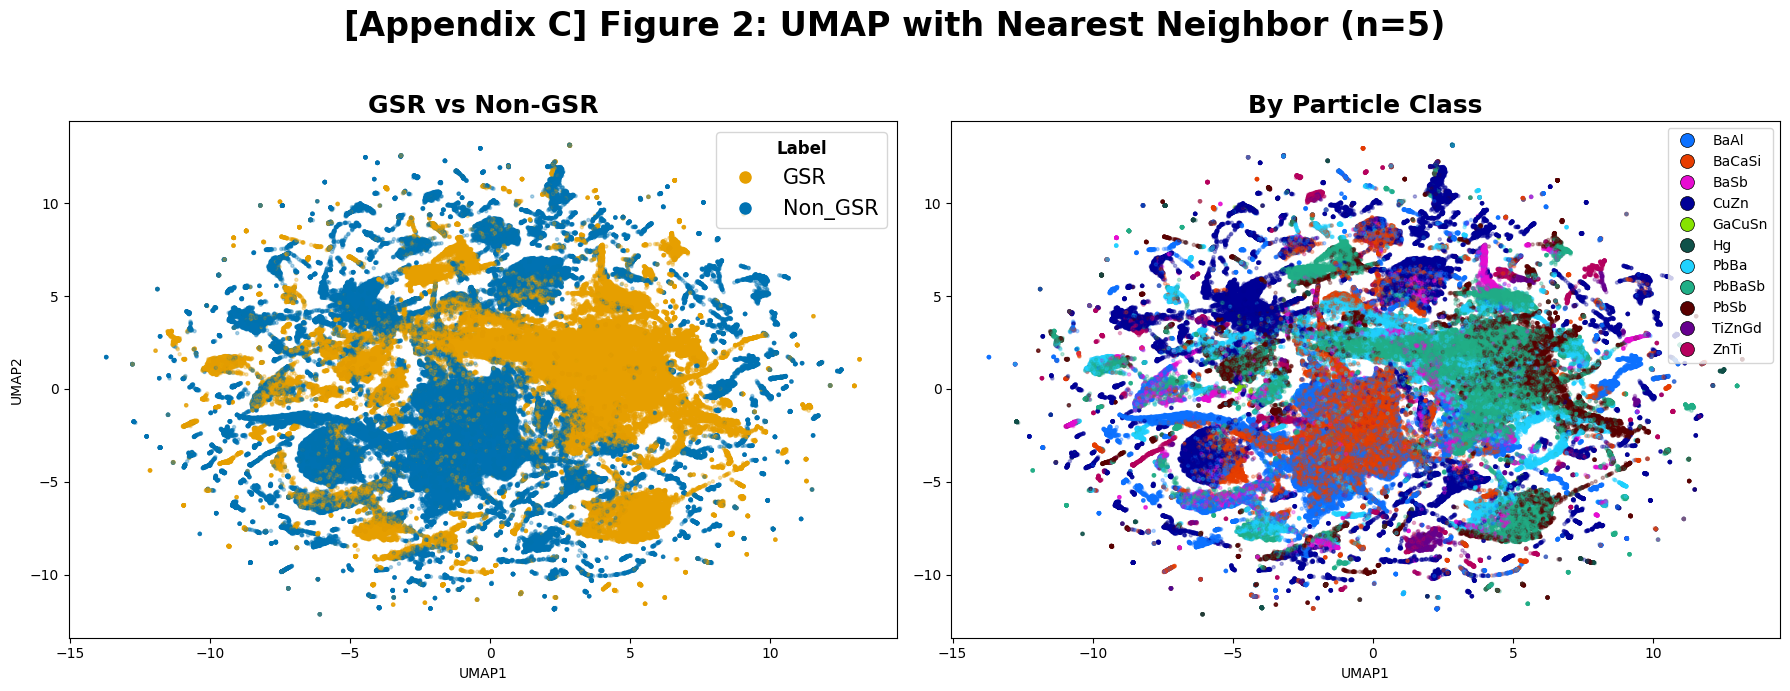

In [ ]:
# Appendix C - Figure 2

# Plot the UMAP results (2 plots) colored by: 1) binary label; 2) particle class
le = LabelEncoder()
class_encoded = le.fit_transform(sample["final_class"])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Colorblind friendly colors
colors = (
    sample["label"]
    .map({"GSR": "#E69F00", "Non_GSR": "#0072B2"})  # orange  # blue
    .values
)
# palette = sns.color_palette("colorblind", n_colors=len(le.classes_))
palette = glasbey.create_palette(palette_size=len(le.classes_), colorblind_safe=True)
point_colors = [palette[i] for i in class_encoded]

# scatter plot for binary labels
axes[0].scatter(X_umap_nn5[:, 0], X_umap_nn5[:, 1], c=colors, alpha=0.3, s=5)
axes[0].set_title("GSR vs Non-GSR", fontsize=18, fontweight="bold")
axes[0].set_xlabel("UMAP1")
axes[0].set_ylabel("UMAP2")

# legend for binary labels
handles = [
    mlines.Line2D(
        [], [], color=colors[1], marker="o", linestyle="None", markersize=8, label="GSR"
    ),
    mlines.Line2D(
        [],
        [],
        color=colors[0],
        marker="o",
        linestyle="None",
        markersize=8,
        label="Non_GSR",
    ),
]
bin_legend = axes[0].legend(handles=handles, loc="upper right", fontsize=15)
bin_legend.set_title("Label", prop={"size": 12, "weight": "bold"})
title = bin_legend.get_title()

# scatter plot for particle classes
scatter = axes[1].scatter(
    X_umap_nn5[:, 0], X_umap_nn5[:, 1], c=point_colors, alpha=0.3, s=5
)
axes[1].set_title("By Particle Class", fontsize=18, fontweight="bold")
axes[1].set_xlabel("UMAP1")

# custom legend for particle classes
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=palette[i],
        markersize=10,
        markeredgecolor="black",
        markeredgewidth=0.5,
        label=cls,
    )
    for i, cls in enumerate(sorted(le.classes_))
]
axes[1].legend(handles=handles, loc="upper right", fontsize=10, ncol=1, markerscale=1)

fig.suptitle(
    "[Appendix C] Figure 2: UMAP with Nearest Neighbor (n=5)",
    fontsize=24,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig("outputs/umap__gsr_vs_non_gsr_3.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# kNN classification accuracy for n_neighbors=5
X_umap_nn5_np = np.array(X_umap_nn5)
knn = KNeighborsClassifier(n_neighbors=5)
labels = np.array(sample["label"].values)
knn_umap_nn5 = cross_val_score(
    knn, X_umap_nn5_np, labels, cv=5, scoring="accuracy"
).mean()

f"kNN classification accuracy for n_neighbors=5: {knn_umap_nn5 * 100:.1f}%"

'kNN classification accuracy for n_neighbors=5: 93.9%'

In [ ]:
# Nearest Neighbor metric:
#   n_neighbors=50 will merge small clusters into larger blobs, emphasizing the broad GSR vs Non-GSR distinction.
#   If the overlap between GSR/Non-GSR still persists, it is strong evidence that the overlap is real and not just an artifact of UMAP embedding

reducer_nn50 = umap.UMAP(
    n_neighbors=50,
    min_dist=0.1,
    n_components=2,
    metric="euclidean",
    random_state=42,
    low_memory=True,
    n_jobs=1
)
X_umap_nn50 = reducer_nn50.fit_transform(X_scaled)

c:\git\datascience-capstone\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


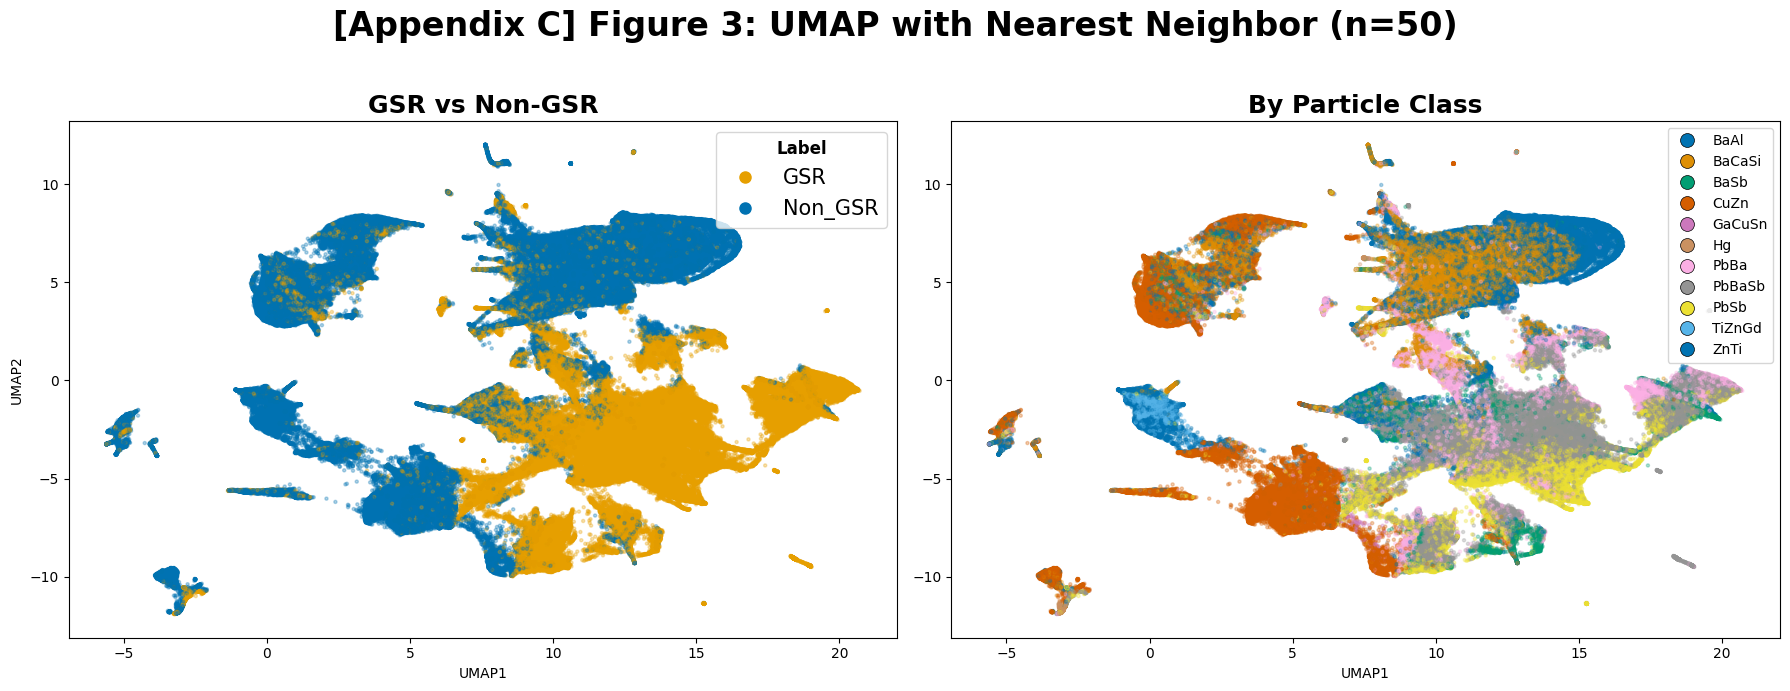

In [ ]:
# APPENDIX C - Figure 3

# Plot the UMAP results (2 plots) colored by: 1) binary label; 2) particle class
le = LabelEncoder()
class_encoded = le.fit_transform(sample["final_class"])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Colorblind friendly colors
colors = (
    sample["label"]
    .map({"GSR": "#E69F00", "Non_GSR": "#0072B2"})  # orange  # blue
    .values
)
palette = sns.color_palette("colorblind", n_colors=len(le.classes_))
# palette = glasbey.create_palette(palette_size=len(le.classes_), colorblind_safe=True)
point_colors = [palette[i] for i in class_encoded]

# scatter plot for binary labels
axes[0].scatter(X_umap_nn50[:, 0], X_umap_nn50[:, 1], c=colors, alpha=0.3, s=5)
axes[0].set_title("GSR vs Non-GSR", fontsize=18, fontweight="bold")
axes[0].set_xlabel("UMAP1")
axes[0].set_ylabel("UMAP2")

# legend for binary labels
handles = [
    mlines.Line2D(
        [], [], color=colors[1], marker="o", linestyle="None", markersize=8, label="GSR"
    ),
    mlines.Line2D(
        [],
        [],
        color=colors[0],
        marker="o",
        linestyle="None",
        markersize=8,
        label="Non_GSR",
    ),
]
bin_legend = axes[0].legend(handles=handles, loc="upper right", fontsize=15)
bin_legend.set_title("Label", prop={"size": 12, "weight": "bold"})
title = bin_legend.get_title()

# scatter plot for particle classes
scatter = axes[1].scatter(
    X_umap_nn50[:, 0], X_umap_nn50[:, 1], c=point_colors, alpha=0.3, s=5
)
axes[1].set_title("By Particle Class", fontsize=18, fontweight="bold")
axes[1].set_xlabel("UMAP1")

# custom legend for particle classes
handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=palette[i],
        markersize=10,
        markeredgecolor="black",
        markeredgewidth=0.5,
        label=cls,
    )
    for i, cls in enumerate(sorted(le.classes_))
]
axes[1].legend(handles=handles, loc="upper right", fontsize=10, ncol=1, markerscale=1)

fig.suptitle(
    "[Appendix C] Figure 3: UMAP with Nearest Neighbor (n=50)",
    fontsize=24,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig("outputs/umap__gsr_vs_non_gsr_4.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# kNN classification accuracy for n_neighbors=50
X_umap_nn50_np = np.array(X_umap_nn50)
knn = KNeighborsClassifier(n_neighbors=50)
labels = np.array(sample["label"].values)
knn_umap_nn50 = cross_val_score(
    knn, X_umap_nn50_np, labels, cv=5, scoring="accuracy"
).mean()

f"kNN classification accuracy for n_neighbors=50: {knn_umap_nn50 * 100:.1f}%"

'kNN classification accuracy for n_neighbors=50: 93.3%'